# **Library**

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498202 sha256=690e1c75f356041547911d9d8deaf19ff5f9c267eb87148405624339192980dc
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
import pandas as pd
import random
import numpy as np
import torch
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# model indobertweet
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW # Import AdamW dari torch.optim
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.nn import CrossEntropyLoss

# model lstm
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# model ml ekstraksi fitur
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import fasttext

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.')
else:
    device = torch.device("cpu")
    print('Tidak ada GPU yang tersedia. Menggunakan CPU untuk pelatihan.')

Ada GPU yang tersedia. Menggunakan GPU untuk pelatihan.


Set Seed for Reproducibility

In [ ]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)
print("Seed telah diatur untuk reproduktibilitas.")

Seed telah diatur untuk reproduktibilitas.


**Konfigurasi**

In [ ]:
# Dataset
FILE_ID = '1zCIipCHY3xvFtgGeFBMLWATXsY96czdi'
INPUT_FILE = 'Slowliving_Label.csv'

# **Load Dataset**

In [ ]:
gdown.download(id=FILE_ID, output=INPUT_FILE, quiet=False)
data = pd.read_csv(INPUT_FILE)
display(data.head(1))
data.info()

Downloading...
From: https://drive.google.com/uc?id=1zCIipCHY3xvFtgGeFBMLWATXsY96czdi
To: /content/Slowliving_Label.csv
100%|██████████| 1.02M/1.02M [00:00<00:00, 12.3MB/s]


,full_text,sentiment,slang,stemming,label
0,bulan di batam ngajarin aku kalo menyesuaikan ...,positif,bulan di batam ngajarin saya kalo menyesuaik...,bulan di batam ngajarin saya kalo sesuai phase...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3417 non-null   object
 1   sentiment  3417 non-null   object
 2   slang      3417 non-null   object
 3   stemming   3417 non-null   object
 4   label      3417 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 133.6+ KB


# **EDA**

/tmp/ipython-input-1306486919.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


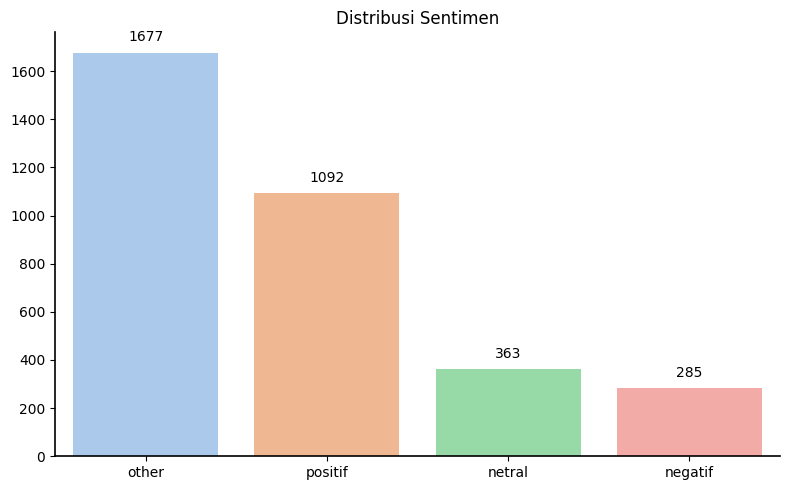

In [ ]:
# Mapping label ke nama sentimen
label_to_sentiment = {0: 'netral', 1: 'positif', 2: 'negatif', 3: 'other'}
data['sentiment'] = data['label'].map(label_to_sentiment)

# Hitung jumlah per sentimen
label_counts = data['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Sentimen')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

==== Prepare Data ====

In [ ]:
data = data[['sentiment', 'stemming', 'label']]
print("\n✅ Dataset dimuat. Contoh:")
display(data.head(2))
data.info()


✅ Dataset dimuat. Contoh:


,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  3417 non-null   object
 1   stemming   3417 non-null   object
 2   label      3417 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 80.2+ KB


==== Skema Label Tanpa Other====

In [ ]:
df = data[data['sentiment'] != 'other'].copy()
df['sentiment'].value_counts()
display(df.head(2))
df.info()

,sentiment,stemming,label
0,positif,bulan di batam ngajarin saya kalo sesuai phase...,1
1,netral,sekali sekali slow living,0


<class 'pandas.core.frame.DataFrame'>
Index: 1740 entries, 0 to 3416
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  1740 non-null   object
 1   stemming   1740 non-null   object
 2   label      1740 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 54.4+ KB


# **Split Data**

70 15 15

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['stemming'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

In [ ]:
# df_train menampung hasil dari xtrain
df_train = pd.DataFrame({'stemming': train_texts, 'label': train_labels})

# Tambahkan kolom 'sentiment' ke df_train dengan memetakan 'label' ke 'sentiment' dari dataframe df/utama
label_to_sentiment = df.set_index('label')['sentiment'].to_dict()
df_train['sentiment'] = df_train['label'].map(label_to_sentiment)

print(f"\n📊 Jumlah data train: {len(df_train)} | val: {len(val_texts)} | test: {len(test_texts)}")
display(df_train.head(2))
df_train.info()


📊 Jumlah data train: 1218 | val: 261 | test: 261


,stemming,label,sentiment
2705,telah presentasi tgl aku mau slow living,1,positif
2377,ngobrol sama bu dinda sampe saya bilang ingin ...,1,positif


<class 'pandas.core.frame.DataFrame'>
Index: 1218 entries, 2705 to 3379
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   stemming   1218 non-null   object
 1   label      1218 non-null   int64 
 2   sentiment  1218 non-null   object
dtypes: int64(1), object(2)
memory usage: 38.1+ KB


/tmp/ipython-input-3125339172.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


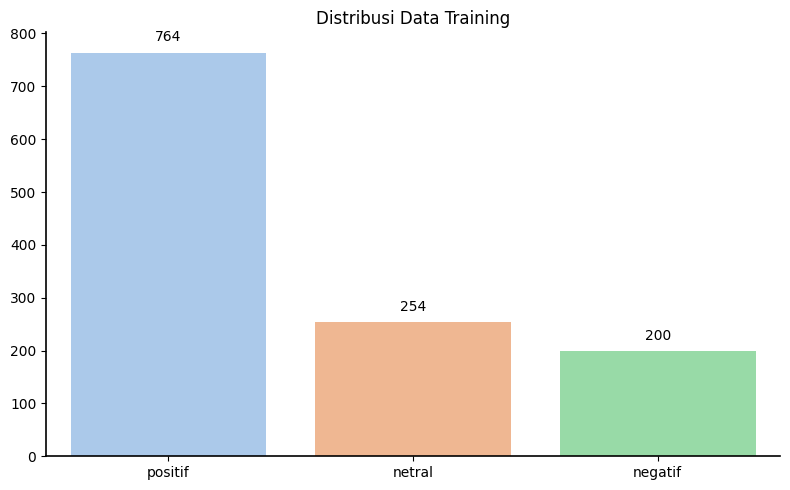

In [ ]:
df_train['sentiment'] = df_train['label'].map(label_to_sentiment)

# Hitung jumlah sentimen
label_counts = df_train['sentiment'].value_counts()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **Model IndoBERTweet**

### **Tokenize Data Loader**

In [ ]:
# Menginisialisasi tokenizer IndoBERTweet
print("\nMenginisialisasi tokenizer IndoBERTweet...")
tokenizer = AutoTokenizer.from_pretrained('indolem/indobertweet-base-uncased')

# Fungsi untuk tokenisasi dan encoding data
def encode_data(tokenizer, texts, labels):
    input_ids = []
    attention_masks = []
    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=128,  # Menetapkan panjang maksimum sequence
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels)
    return TensorDataset(input_ids, attention_masks, labels)

# Menerapkan fungsi encoding ke setiap set data
train_dataset = encode_data(tokenizer, df_train['stemming'].tolist(), df_train['label'].tolist())
val_dataset = encode_data(tokenizer, val_texts.tolist(), val_labels.tolist())
test_dataset = encode_data(tokenizer, test_texts.tolist(), test_labels.tolist())

# Membuat DataLoader untuk memproses data dalam batch
batch_size = 16
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)


Menginisialisasi tokenizer IndoBERTweet...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### **Load Model**

In [ ]:
num_labels = 3
model = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobertweet-base-uncased',
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# Mengatur optimizer dan scheduler dengan learning rate dan epsilon yang ditentukan
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 4
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### **Training**

In [ ]:
print("\n--- Memulai Pelatihan ---")
# Menyimpan riwayat metrik untuk visualisasi
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience = 1
patience_counter = 0
best_model_state = None

for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")

    # Mode pelatihan (training)
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0

    for step, batch in enumerate(train_dataloader):
        if step % 50 == 0 and not step == 0:
            print(f'  Batch {step} dari {len(train_dataloader)}.')

        # Memindahkan batch data ke device (GPU/CPU)
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        total_train_loss += loss.item()

        # Menghitung akurasi batch
        preds = torch.argmax(logits, dim=1)
        total_train_accuracy += (preds == b_labels).sum().item() / len(b_labels)

        loss.backward() # Propagasi balik
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Mencegah exploding gradients
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_accuracy / len(train_dataloader)

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)

    print(f"  Rata-rata loss pelatihan: {avg_train_loss:.2f}")
    print(f"  Rata-rata akurasi pelatihan: {avg_train_acc:.2f}")

    # Mode evaluasi (validation)
    model.eval()
    total_eval_loss = 0
    total_eval_accuracy = 0

    for batch in val_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        logits = outputs.logits
        total_eval_loss += loss.item()

        # Menghitung akurasi validasi
        preds = torch.argmax(logits, dim=1)
        total_eval_accuracy += (preds == b_labels).sum().item() / len(b_labels)

    avg_val_loss = total_eval_loss / len(val_dataloader)
    avg_val_acc = total_eval_accuracy / len(val_dataloader)

    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)

    print(f"  Rata-rata loss validasi: {avg_val_loss:.2f}")
    print(f"  Rata-rata akurasi validasi: {avg_val_acc:.2f}")

    # Implementasi Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
        print("  Loss validasi menurun. Menyimpan model terbaik.")
    else:
        patience_counter += 1
        print(f"  Loss validasi tidak menurun. Patience counter: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"  Early stopping! Pelatihan dihentikan setelah {epoch_i + 1} epoch.")
            break

# Muat kembali model terbaik yang telah disimpan
if best_model_state is not None:
    model.load_state_dict(best_model_state)


--- Memulai Pelatihan ---

======== Epoch 1 / 4 ========
  Batch 50 dari 77.
  Rata-rata loss pelatihan: 0.88
  Rata-rata akurasi pelatihan: 0.63
  Rata-rata loss validasi: 0.84
  Rata-rata akurasi validasi: 0.63
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 2 / 4 ========
  Batch 50 dari 77.
  Rata-rata loss pelatihan: 0.75
  Rata-rata akurasi pelatihan: 0.66
  Rata-rata loss validasi: 0.71
  Rata-rata akurasi validasi: 0.66
  Loss validasi menurun. Menyimpan model terbaik.

======== Epoch 3 / 4 ========
  Batch 50 dari 77.
  Rata-rata loss pelatihan: 0.60
  Rata-rata akurasi pelatihan: 0.76
  Rata-rata loss validasi: 0.72
  Rata-rata akurasi validasi: 0.69
  Loss validasi tidak menurun. Patience counter: 1/1
  Early stopping! Pelatihan dihentikan setelah 3 epoch.


apikey a5153cecda5fef1b45867e96aa08c5cc24f8771a

### **Evaluasi Model**


Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.29      0.09      0.14        54
           1       0.70      0.96      0.81       164
           2       0.47      0.19      0.27        43

    accuracy                           0.66       261
   macro avg       0.49      0.41      0.41       261
weighted avg       0.58      0.66      0.58       261



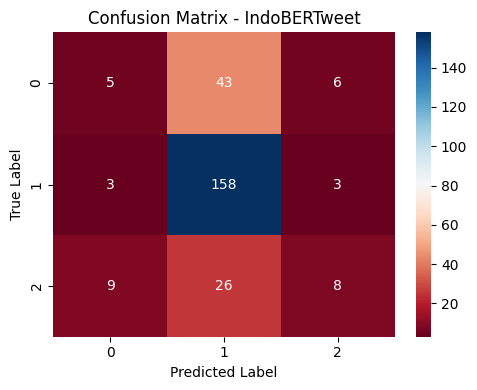

Akurasi model pada data pengujian: 0.6552


In [ ]:
model.eval()

predictions, true_labels = [], []
for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    predictions.extend(np.argmax(logits, axis=1).flatten())
    true_labels.extend(label_ids.flatten())

print("\nLaporan Klasifikasi:")
# Laporan yang mencakup Precision, Recall, dan F1-score
print(classification_report(true_labels, predictions))

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=range(model.config.num_labels),
            yticklabels=range(model.config.num_labels))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - IndoBERTweet")
plt.tight_layout()
plt.show()

test_accuracy = accuracy_score(true_labels, predictions)
print(f"Akurasi model pada data pengujian: {test_accuracy:.4f}")

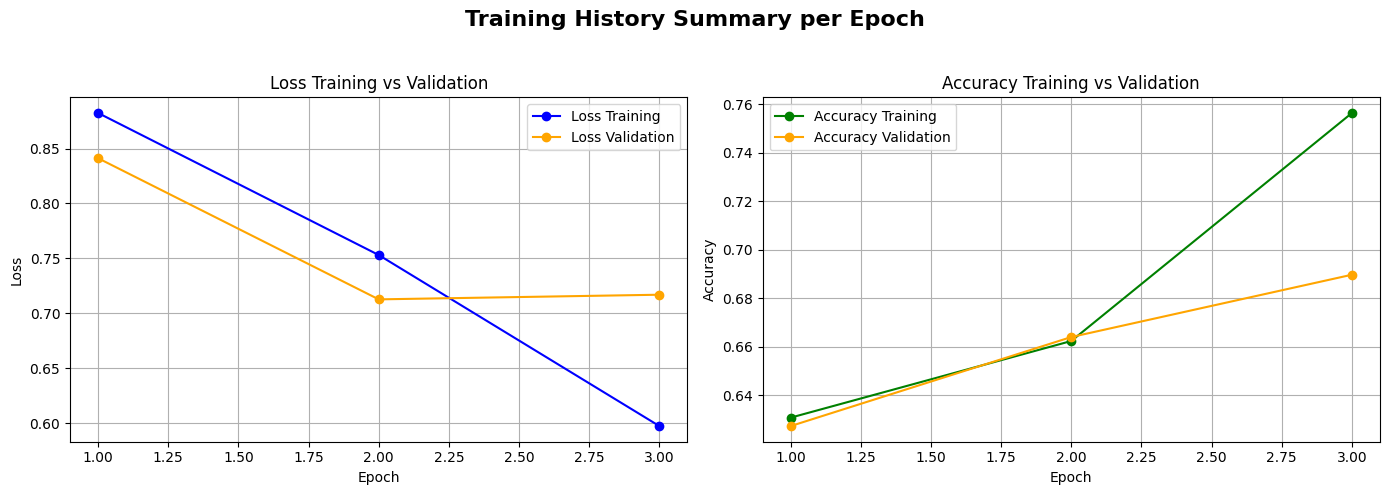

In [ ]:
epochs_run = len(history['train_loss'])
epochs_range = range(1, epochs_run + 1)

# Buat 1 baris, 2 kolom plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Loss ===
ax1.plot(epochs_range, history['train_loss'], label='Loss Training', color='blue', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Loss Validation', color='orange', marker='o')
ax1.set_title('Loss Training vs Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# === Plot 2: Accuracy ===
ax2.plot(epochs_range, history['train_acc'], label='Accuracy Training', color='green', marker='o')
ax2.plot(epochs_range, history['val_acc'], label='Accuracy Validation', color='orange', marker='o')
ax2.set_title('Accuracy Training vs Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Judul
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Error Analisis**

In [ ]:
print("\n--- Analisis Sampel Teks yang Salah Diklasifikasikan ---")

sentiment_to_label = {
    'netral': 0,
    'positif': 1,
    'negatif': 2,
    'other': 3
}

# Konversi true_labels dan predictions menjadi array numpy untuk perbandingan
true_labels_np = np.array(true_labels)
predictions_np = np.array(predictions)

# Mencari indeks di mana true_labels tidak sama dengan predictions
misclassified_indices = np.where(true_labels_np != predictions_np)[0]

print(f"Total sampel yang salah diklasifikasikan: {len(misclassified_indices)}")

# Reverse the label mapping to get sentiment strings from labels
label_to_sentiment = {v: k for k, v in sentiment_to_label.items()}

# Creating DataFrame for error analysis
misclassified_data = {
    'Teks': [test_texts.iloc[i] for i in misclassified_indices], # Use iloc for positional indexing
    'True Label (Sentiment)': [label_to_sentiment[true_labels_np[i]] for i in misclassified_indices], # Map label to sentiment
    'Predicted Label (Sentiment)': [label_to_sentiment[predictions_np[i]] for i in misclassified_indices] # Map label to sentiment
}
misclassified_df = pd.DataFrame(misclassified_data)

# Displaying all misclassified samples for further analysis
print("\nMenampilkan semua sampel teks yang salah diklasifikasikan:")
display(misclassified_df)


--- Analisis Sampel Teks yang Salah Diklasifikasikan ---
Total sampel yang salah diklasifikasikan: 90

Menampilkan semua sampel teks yang salah diklasifikasikan:


,Teks,True Label (Sentiment),Predicted Label (Sentiment)
0,tidak sadar nyata lama hustle banget serba mul...,netral,positif
1,yo opo se slow living iku,netral,negatif
2,kkn tidak cocok buat saya slow living,negatif,positif
3,cw gaji work dilema kerja ln jam hari minggu m...,negatif,positif
4,napa tiap saya buru dapetnya gojek slow living...,netral,positif
...,...,...,...
85,kalo ingin slow living masuk di mana,netral,positif
86,saya pikir lama saya slow living banget yaaa k...,netral,positif
87,hari hari pusing apa sudah saat slow living,netral,positif
88,masiiih harus ngajak pakar slow living kita,netral,positif


In [ ]:
# misclassified_df.to_csv('misclassified_sempel.csv', index=False)

# **Model LSTM**

Langsung lanjut ke deploy model sampai ke tahap evaluasi

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

## **Tokenize Padding**

In [ ]:
# Parameters for tokenization and padding
vocab_size = 10000  # Adjust based on your vocabulary size
max_length = 128    # Should be consistent with the BERT model's max_length
embedding_dim = 100 # Dimension of the word embeddings

# Initialize and fit the tokenizer on the training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train['stemming'])

# Convert texts to sequences of integers
train_sequences = tokenizer.texts_to_sequences(df_train['stemming'])
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Pad the sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Data preparation for LSTM complete.")
print("Shape of training data:", train_padded.shape)
print("Shape of validation data:", val_padded.shape)
print("Shape of test data:", test_padded.shape)

Data preparation for LSTM complete.
Shape of training data: (1218, 128)
Shape of validation data: (261, 128)
Shape of test data: (261, 128)


In [ ]:
# Calculate class weights to handle potential class imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)

# Convert to dictionary format required by Keras model.fit
class_weights_dict = dict(enumerate(class_weights))

## **Deploy LSTM**

In [ ]:
# Define the LSTM model with the specified architecture
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dense(len(np.unique(df_train['label'])), activation='softmax') # Use the number of unique labels from the augmented training data
])

# Compile the model
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build and summarize the model
model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()

# Callback EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("\n--- Memulai Pelatihan LSTM ---")
history_lstm = model_lstm.fit(
    train_padded, df_train['label'], # Use the padded training data and augmented labels
    epochs=20,
    batch_size=16,
    validation_data=(val_padded, val_labels), # Use the padded validation data and validation labels
    class_weight=class_weights_dict, # Use the calculated class weights dictionary
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,419 (3.98 MB)

 Trainable params: 1,044,419 (3.98 MB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Pelatihan LSTM ---
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2965 - loss: 1.1800 - val_accuracy: 0.6322 - val_loss: 1.1082
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4077 - loss: 1.1544 - val_accuracy: 0.6284 - val_loss: 1.0507
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4665 - loss: 1.0977 - val_accuracy: 0.5556 - val_loss: 0.9292
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7691 - loss: 0.6780 - val_accuracy: 0.5900 - val_loss: 0.9499
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8712 - loss: 0.3829 - val_accuracy: 0.6552 - val_loss: 1.1439
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9474 - loss: 0.2129 - val_accuracy: 0.6552 - val_loss: 1.3221
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9471 - loss: 0.1859 - val_accuracy: 0.6475 - val_loss: 1.2600
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9796 - loss: 0.09

## **Evaluasi Model**


--- Evaluasi Model LSTM ---
Test Loss: 1.2776
Test Accuracy: 0.6054
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.17      0.22        54
           1       0.69      0.84      0.76       164
           2       0.33      0.26      0.29        43

    accuracy                           0.61       261
   macro avg       0.45      0.42      0.42       261
weighted avg       0.55      0.61      0.57       261



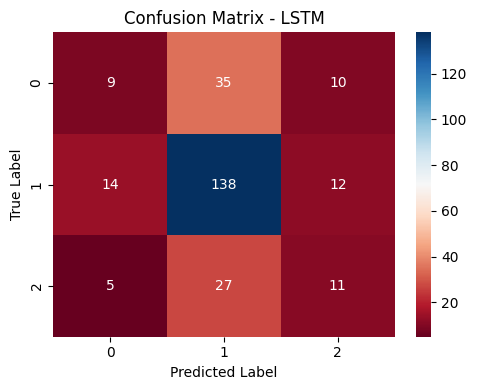

In [ ]:
# Evaluate the model on the test data
print("\n--- Evaluasi Model LSTM ---")
test_loss, test_acc = model_lstm.evaluate(test_padded, test_labels, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
y_pred = model_lstm.predict(test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_classes))

# Generate confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',
            xticklabels=np.unique(test_labels),  # Use unique labels from test set
            yticklabels=np.unique(test_labels))  # Use unique labels from test set
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.show()

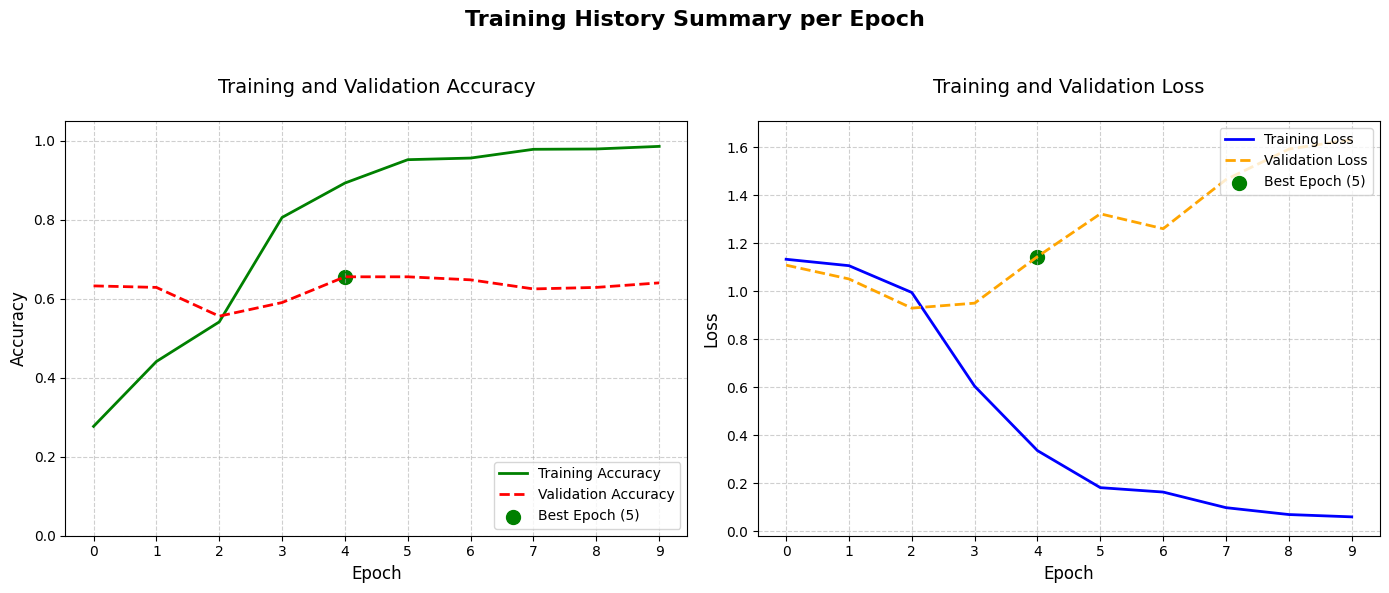

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get the number of epochs the model actually trained for
num_epochs = len(history_lstm.history['accuracy'])
epochs_range = range(num_epochs)

# Get the best epoch from the EarlyStopping callback
# If early stopping occurred, best_epoch is where performance was best
# If not, the last epoch is the best epoch in terms of performance on the monitored metric during training
if early_stop.stopped_epoch > 0:
    best_epoch = early_stop.best_epoch
else:
    best_epoch = num_epochs - 1 # If no early stopping, the last epoch is technically the "best" among the run epochs


# Plot Accuracy
axes[0].plot(epochs_range, history_lstm.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[0].plot(epochs_range, history_lstm.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
axes[0].scatter(best_epoch, history_lstm.history['val_accuracy'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[0].set_title('Training and Validation Accuracy', fontsize=14, pad=20)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim([0, 1.05])  # Adjust y-axis limit for better visualization
axes[0].set_xticks(epochs_range) # Set x-ticks to match the number of epochs


# Plot Loss
axes[1].plot(epochs_range, history_lstm.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(epochs_range, history_lstm.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
axes[1].scatter(best_epoch, history_lstm.history['val_loss'][best_epoch], color='green', s=100, label=f'Best Epoch ({best_epoch + 1})') # Mark the best epoch
axes[1].set_title('Training and Validation Loss', fontsize=14, pad=20)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(epochs_range) # Set x-ticks to match the number of epochs


# Atur layout dan spacing
fig.suptitle('Training History Summary per Epoch', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# **Model Machine Learning**

In [ ]:
print("Total training data:", train_texts.shape[0])

Total training data: 1218


### EDA

/tmp/ipython-input-3305301575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


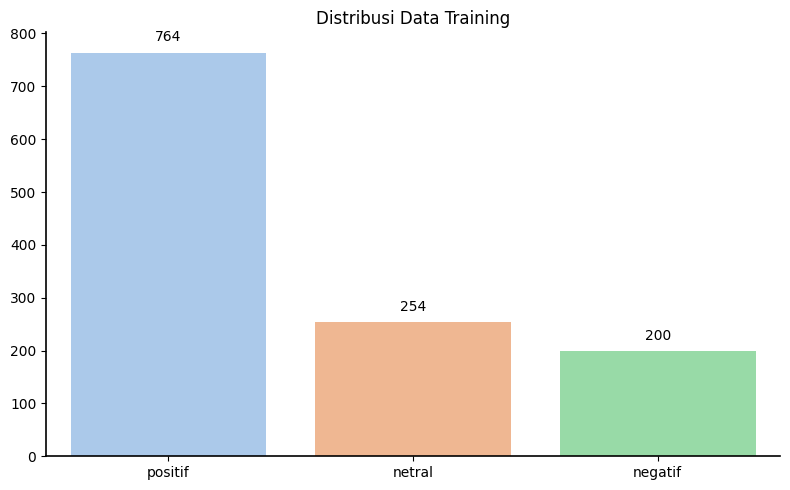

In [ ]:
label_counts_train = train_labels.value_counts().sort_index()

# Plot minimalis
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

# Hilangkan elemen tambahan
plt.title('Distribusi Data Training')
ax.set_xlabel("")            # Hilangkan label sumbu X
ax.set_ylabel("")            # Hilangkan label sumbu Y
ax.legend([],[], frameon=False)  # Hilangkan legend

# Tambahkan garis sumbu X dan Y saja
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (Opsional) Tambahkan garis dasar sumbu X/Y agar tetap terlihat
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# (Opsional) Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    ax.text(i, value + max(label_counts.values)*0.02, str(value),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### **Ekstraksi Fitur**

Menggunakan BoW, TF-IDF dan N-Grams

In [ ]:
vectorizers_bow = {
    'BoW': CountVectorizer(max_features=5000),
}
vectorizers_tfidf = {
    'TFIDF': TfidfVectorizer(max_features=5000),
}
vectorizers_unigram = {
    'Unigram': CountVectorizer(max_features=5000, ngram_range=(1, 1)),
}
vectorizers_bigram = {
    'Bigram': CountVectorizer(max_features=5000, ngram_range=(2, 2)),
}
vectorizers_trigram = {
    'Trigram': CountVectorizer(max_features=5000, ngram_range=(3, 3)),
}

### **Evaluasi Model**

Konfigurasi Model ML

In [ ]:
# Inisialisasi model
models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(C=1.0, solver='liblinear', class_weight='balanced',max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=40, min_samples_leaf=3, min_samples_split=2, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, min_samples_split=3, min_samples_leaf=3, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='linear', C=0.5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05, colsample_bytree=0.8, subsample=0.8, gamma=0.2, eval_metric='mlogloss', random_state=42),
}

BoW


======== Vectorizer: BoW ========

Model: Naive Bayes
Test Accuracy: 0.5900
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.15      0.20        54
           1       0.66      0.84      0.74       164
           2       0.30      0.19      0.23        43

    accuracy                           0.59       261
   macro avg       0.42      0.39      0.39       261
weighted avg       0.53      0.59      0.55       261



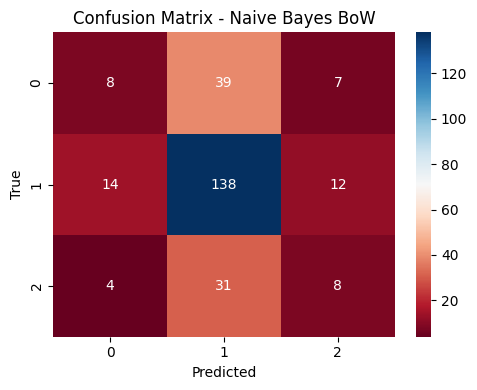


Model: Logistic Regression
Test Accuracy: 0.5824
Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.17      0.20        54
           1       0.69      0.82      0.75       164
           2       0.27      0.21      0.24        43

    accuracy                           0.58       261
   macro avg       0.41      0.40      0.40       261
weighted avg       0.53      0.58      0.55       261



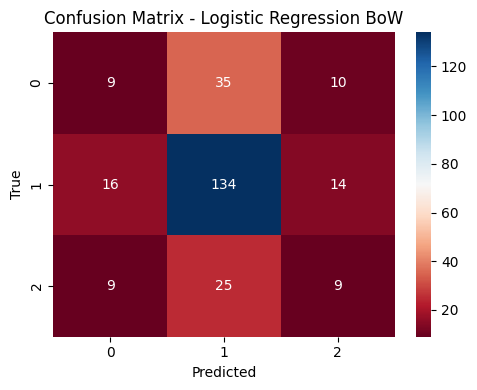


Model: Random Forest
Test Accuracy: 0.5670
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.30      0.31        54
           1       0.74      0.71      0.73       164
           2       0.27      0.35      0.31        43

    accuracy                           0.57       261
   macro avg       0.45      0.45      0.45       261
weighted avg       0.58      0.57      0.57       261



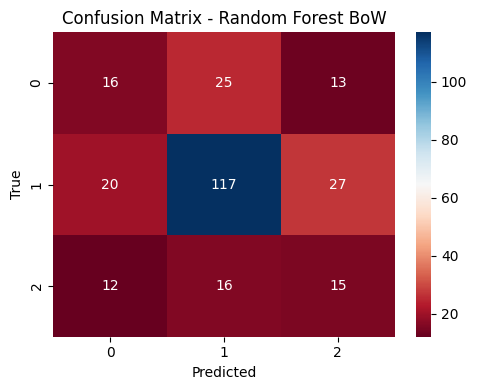


Model: Decision Tree
Test Accuracy: 0.3831
Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.48      0.31        54
           1       0.73      0.37      0.49       164
           2       0.21      0.30      0.25        43

    accuracy                           0.38       261
   macro avg       0.39      0.39      0.35       261
weighted avg       0.54      0.38      0.41       261



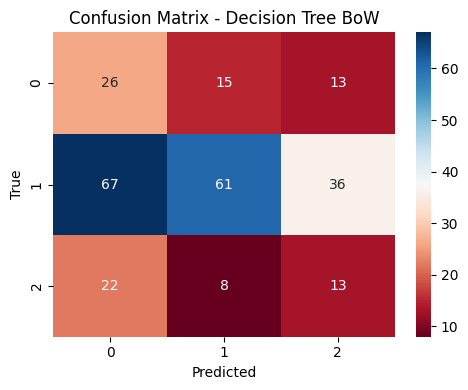


Model: SVM
Test Accuracy: 0.6015
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.30      0.32        54
           1       0.75      0.78      0.77       164
           2       0.29      0.30      0.30        43

    accuracy                           0.60       261
   macro avg       0.46      0.46      0.46       261
weighted avg       0.59      0.60      0.60       261



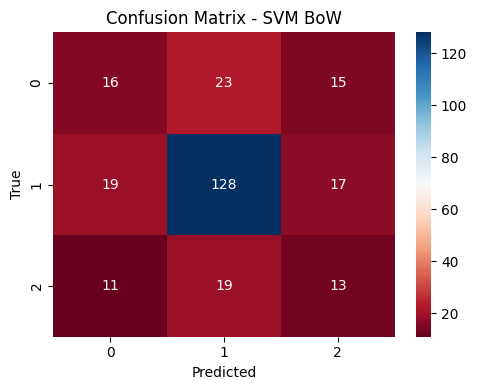


Model: XGBoost
Test Accuracy: 0.6130
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.09      0.14        54
           1       0.67      0.91      0.77       164
           2       0.26      0.12      0.16        43

    accuracy                           0.61       261
   macro avg       0.40      0.37      0.36       261
weighted avg       0.52      0.61      0.54       261



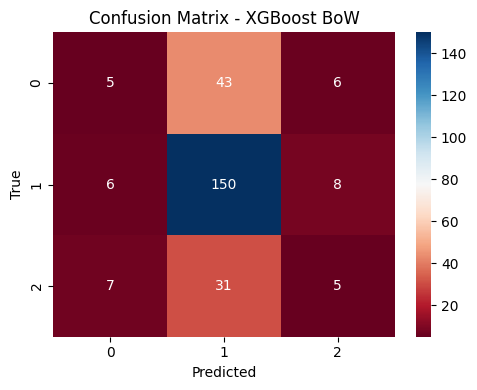

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bow.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


TF-IDF


======== Vectorizer: TFIDF ========

Model: Naive Bayes
Test Accuracy: 0.6207
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.11      0.17        54
           1       0.65      0.93      0.76       164
           2       0.33      0.07      0.12        43

    accuracy                           0.62       261
   macro avg       0.46      0.37      0.35       261
weighted avg       0.54      0.62      0.53       261



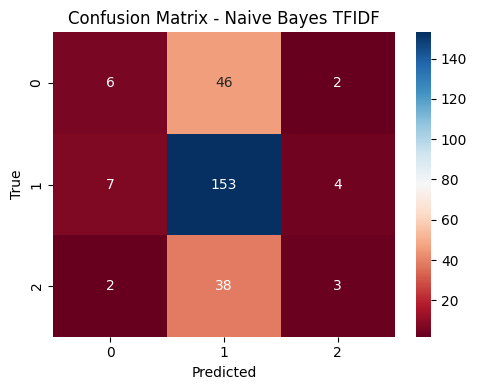


Model: Logistic Regression
Test Accuracy: 0.6437
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.13      0.20        54
           1       0.67      0.94      0.78       164
           2       0.41      0.16      0.23        43

    accuracy                           0.64       261
   macro avg       0.52      0.41      0.41       261
weighted avg       0.59      0.64      0.57       261



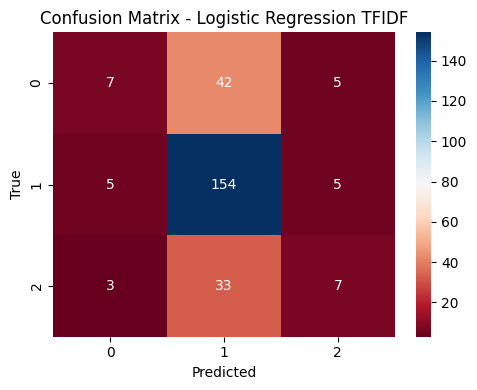


Model: Random Forest
Test Accuracy: 0.5249
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.33      0.32        54
           1       0.70      0.65      0.68       164
           2       0.24      0.28      0.26        43

    accuracy                           0.52       261
   macro avg       0.42      0.42      0.42       261
weighted avg       0.55      0.52      0.53       261



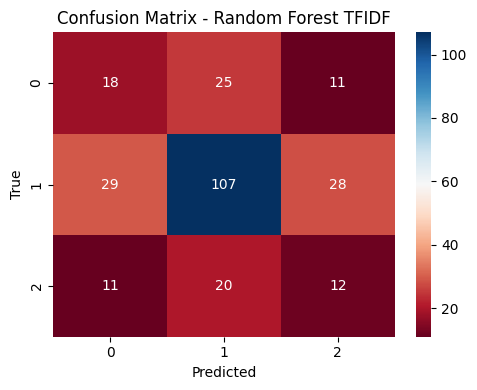


Model: Decision Tree
Test Accuracy: 0.4023
Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.28      0.24        54
           1       0.68      0.44      0.53       164
           2       0.22      0.42      0.29        43

    accuracy                           0.40       261
   macro avg       0.37      0.38      0.35       261
weighted avg       0.51      0.40      0.43       261



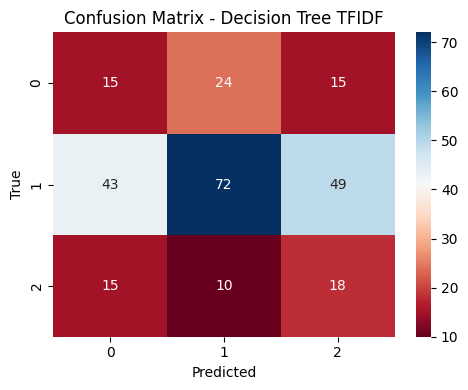


Model: SVM
Test Accuracy: 0.5517
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.37      0.35        54
           1       0.75      0.66      0.70       164
           2       0.29      0.37      0.32        43

    accuracy                           0.55       261
   macro avg       0.45      0.47      0.46       261
weighted avg       0.59      0.55      0.57       261



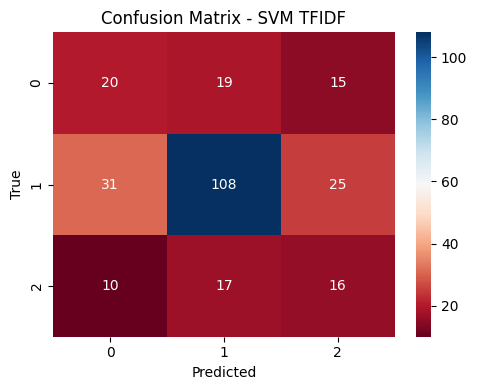


Model: XGBoost
Test Accuracy: 0.5824
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.02      0.03        54
           1       0.65      0.90      0.75       164
           2       0.25      0.09      0.14        43

    accuracy                           0.58       261
   macro avg       0.32      0.34      0.31       261
weighted avg       0.46      0.58      0.50       261



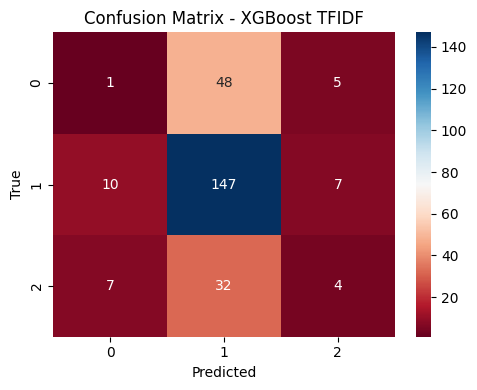

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_tfidf.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Uni Gram


======== Vectorizer: Unigram ========

Model: Naive Bayes
Test Accuracy: 0.5900
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.15      0.20        54
           1       0.66      0.84      0.74       164
           2       0.30      0.19      0.23        43

    accuracy                           0.59       261
   macro avg       0.42      0.39      0.39       261
weighted avg       0.53      0.59      0.55       261



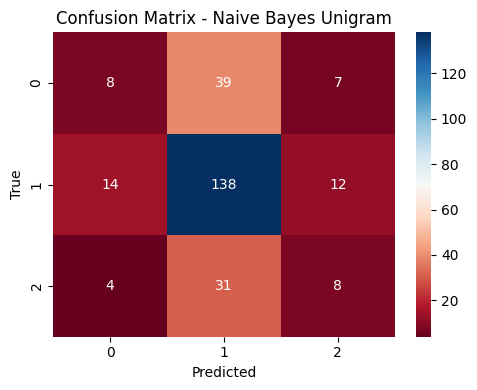


Model: Logistic Regression
Test Accuracy: 0.5824
Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.17      0.20        54
           1       0.69      0.82      0.75       164
           2       0.27      0.21      0.24        43

    accuracy                           0.58       261
   macro avg       0.41      0.40      0.40       261
weighted avg       0.53      0.58      0.55       261



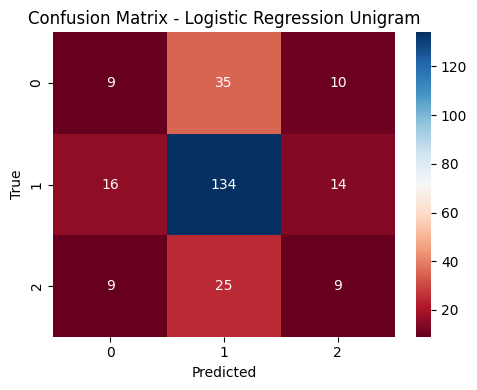


Model: Random Forest
Test Accuracy: 0.5670
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.30      0.31        54
           1       0.74      0.71      0.73       164
           2       0.27      0.35      0.31        43

    accuracy                           0.57       261
   macro avg       0.45      0.45      0.45       261
weighted avg       0.58      0.57      0.57       261



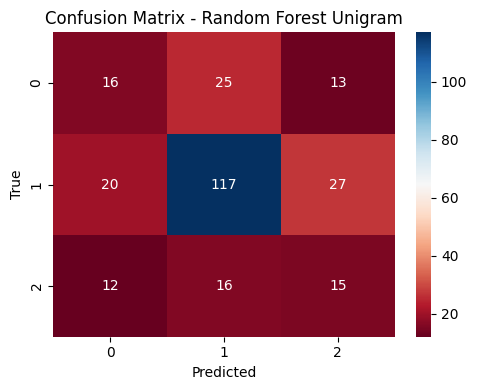


Model: Decision Tree
Test Accuracy: 0.3831
Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.48      0.31        54
           1       0.73      0.37      0.49       164
           2       0.21      0.30      0.25        43

    accuracy                           0.38       261
   macro avg       0.39      0.39      0.35       261
weighted avg       0.54      0.38      0.41       261



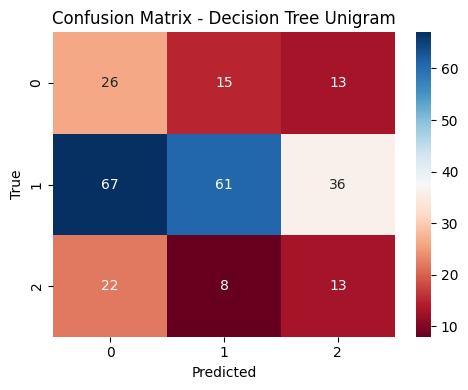


Model: SVM
Test Accuracy: 0.6015
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.30      0.32        54
           1       0.75      0.78      0.77       164
           2       0.29      0.30      0.30        43

    accuracy                           0.60       261
   macro avg       0.46      0.46      0.46       261
weighted avg       0.59      0.60      0.60       261



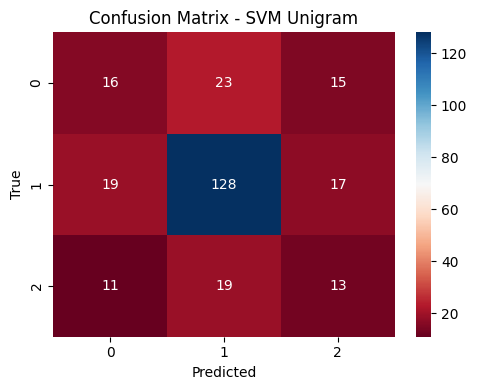


Model: XGBoost
Test Accuracy: 0.6130
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.09      0.14        54
           1       0.67      0.91      0.77       164
           2       0.26      0.12      0.16        43

    accuracy                           0.61       261
   macro avg       0.40      0.37      0.36       261
weighted avg       0.52      0.61      0.54       261



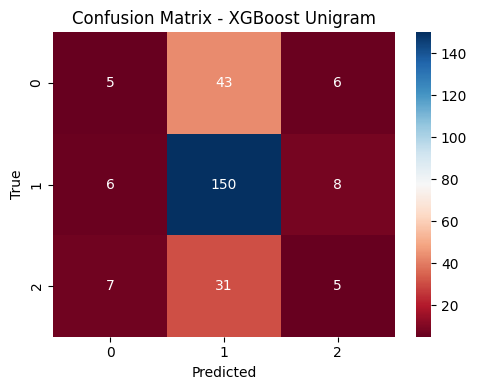

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_unigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Bi Gram


======== Vectorizer: Bigram ========

Model: Naive Bayes
Test Accuracy: 0.5594
Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.11      0.15        54
           1       0.67      0.79      0.73       164
           2       0.26      0.23      0.24        43

    accuracy                           0.56       261
   macro avg       0.38      0.38      0.37       261
weighted avg       0.51      0.56      0.53       261



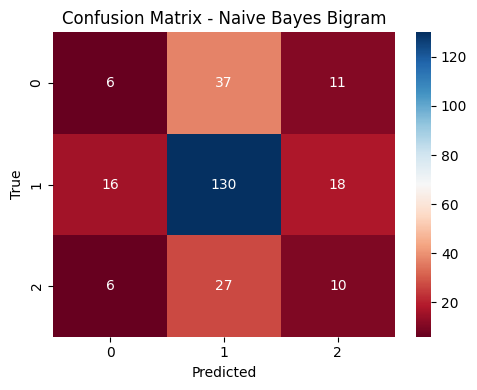


Model: Logistic Regression
Test Accuracy: 0.6054
Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.06      0.09        54
           1       0.66      0.88      0.75       164
           2       0.41      0.26      0.31        43

    accuracy                           0.61       261
   macro avg       0.42      0.40      0.38       261
weighted avg       0.52      0.61      0.54       261



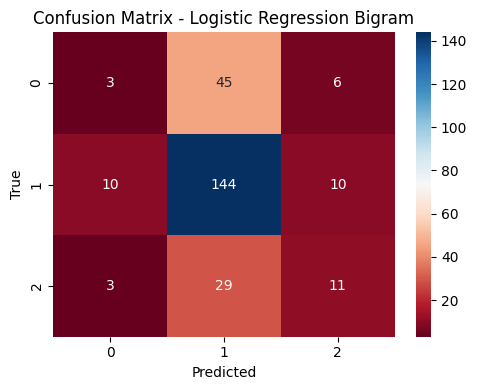


Model: Random Forest
Test Accuracy: 0.4789
Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.13      0.14        54
           1       0.67      0.63      0.65       164
           2       0.25      0.35      0.29        43

    accuracy                           0.48       261
   macro avg       0.36      0.37      0.36       261
weighted avg       0.49      0.48      0.48       261



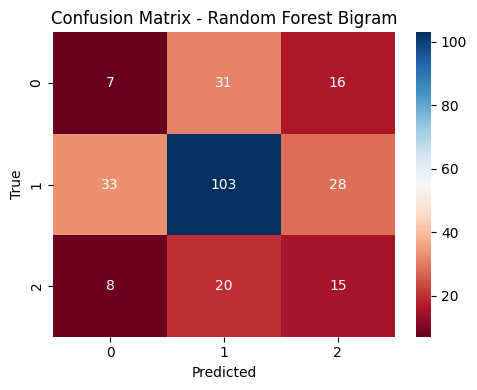


Model: Decision Tree
Test Accuracy: 0.5364
Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.11      0.14        54
           1       0.65      0.73      0.68       164
           2       0.33      0.35      0.34        43

    accuracy                           0.54       261
   macro avg       0.39      0.40      0.39       261
weighted avg       0.50      0.54      0.51       261



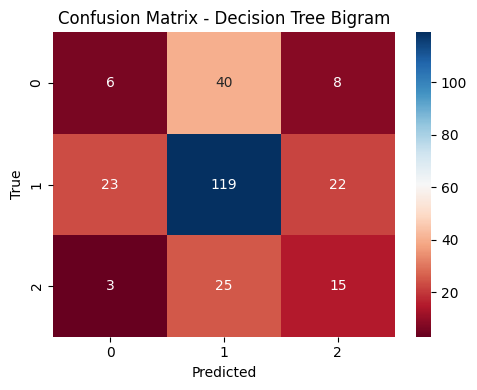


Model: SVM
Test Accuracy: 0.5747
Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.06      0.08        54
           1       0.66      0.82      0.73       164
           2       0.36      0.28      0.32        43

    accuracy                           0.57       261
   macro avg       0.38      0.39      0.38       261
weighted avg       0.50      0.57      0.53       261



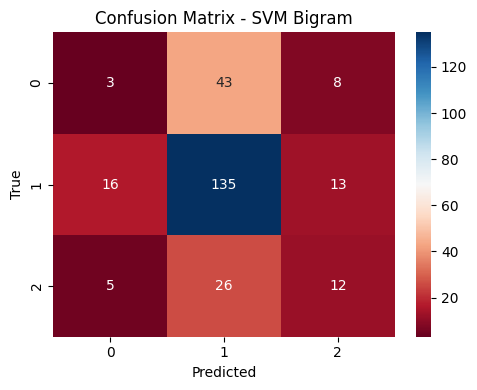


Model: XGBoost
Test Accuracy: 0.5747
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.02      0.03        54
           1       0.65      0.86      0.74       164
           2       0.30      0.19      0.23        43

    accuracy                           0.57       261
   macro avg       0.34      0.35      0.33       261
weighted avg       0.47      0.57      0.51       261



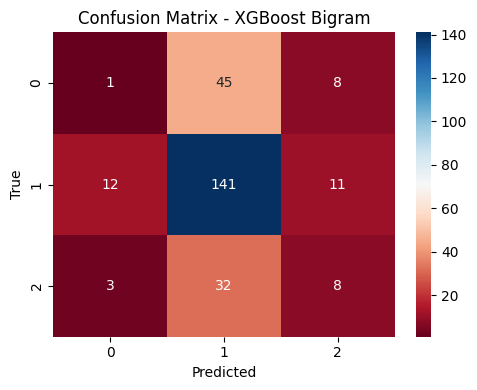

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_bigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


Tri Gram


======== Vectorizer: Trigram ========

Model: Naive Bayes
Test Accuracy: 0.5670
Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.13      0.18        54
           1       0.64      0.82      0.72       164
           2       0.23      0.16      0.19        43

    accuracy                           0.57       261
   macro avg       0.40      0.37      0.36       261
weighted avg       0.51      0.57      0.52       261



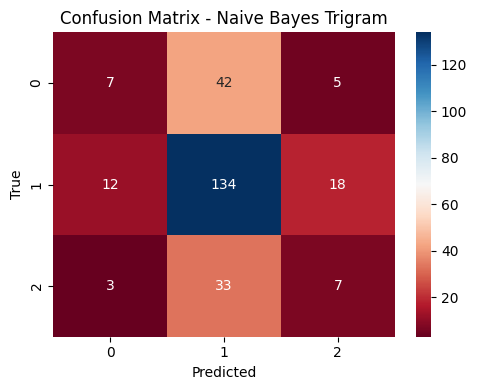


Model: Logistic Regression
Test Accuracy: 0.5939
Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.04      0.06        54
           1       0.65      0.90      0.76       164
           2       0.23      0.12      0.15        43

    accuracy                           0.59       261
   macro avg       0.35      0.35      0.32       261
weighted avg       0.48      0.59      0.51       261



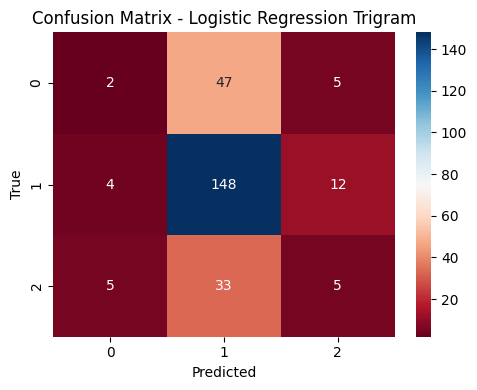


Model: Random Forest
Test Accuracy: 0.5479
Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.09      0.13        54
           1       0.66      0.77      0.71       164
           2       0.24      0.28      0.26        43

    accuracy                           0.55       261
   macro avg       0.38      0.38      0.37       261
weighted avg       0.51      0.55      0.52       261



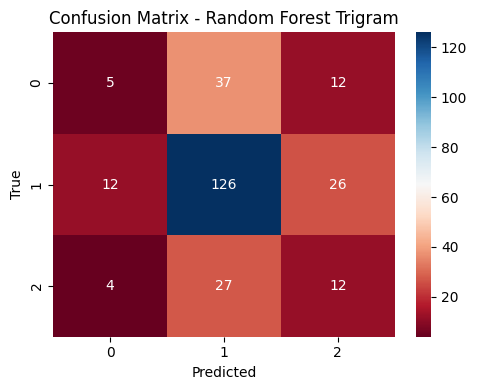


Model: Decision Tree
Test Accuracy: 0.2759
Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.67      0.33        54
           1       0.78      0.15      0.26       164
           2       0.17      0.26      0.20        43

    accuracy                           0.28       261
   macro avg       0.39      0.36      0.26       261
weighted avg       0.56      0.28      0.26       261



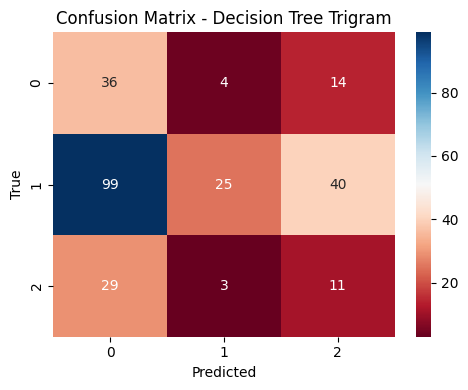


Model: SVM
Test Accuracy: 0.5709
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.09      0.14        54
           1       0.64      0.84      0.73       164
           2       0.21      0.14      0.17        43

    accuracy                           0.57       261
   macro avg       0.38      0.36      0.35       261
weighted avg       0.50      0.57      0.51       261



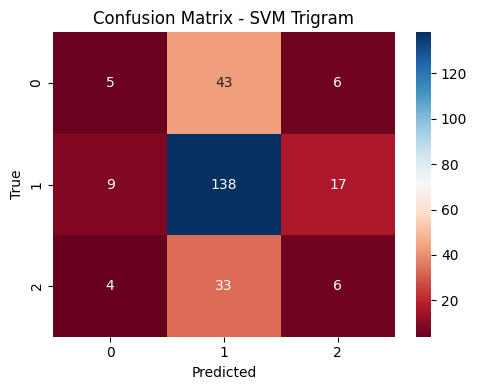


Model: XGBoost
Test Accuracy: 0.5862
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.04      0.07        54
           1       0.64      0.88      0.74       164
           2       0.21      0.14      0.17        43

    accuracy                           0.59       261
   macro avg       0.39      0.35      0.33       261
weighted avg       0.51      0.59      0.51       261



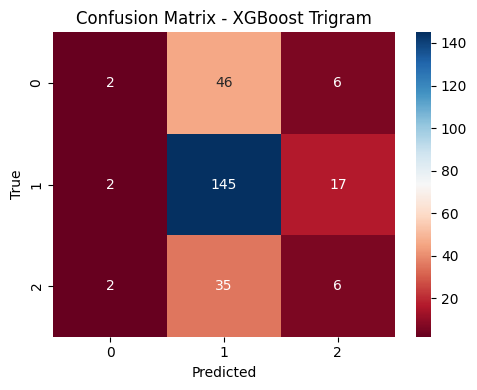

In [ ]:
# Buat vectorizer dan model loop
for vec_name, vectorizer in vectorizers_trigram.items():
    print(f"\n======== Vectorizer: {vec_name} ========")

    # Transform teks
    X_train_vec = vectorizer.fit_transform(train_texts)
    X_test_vec = vectorizer.transform(test_texts)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Training
        model.fit(X_train_vec, train_labels)

        # Prediksi
        y_pred = model.predict(X_test_vec)

        # Evaluasi
        acc = accuracy_score(test_labels, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(test_labels, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)

        # Visualisasi
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
                    xticklabels=np.unique(test_labels),
                    yticklabels=np.unique(test_labels))
        plt.title(f"Confusion Matrix - {model_name} {vec_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()
